# Photonic FBQC on ITensor — the PsiQuantum **6-ring** fusion network

This notebook follows the section order and visual teaching style of the original, but rebuilds the physics around the **canonical six-photon resource** described by Bartolucci *et al.*

Three rules are enforced throughout:

1. A six-ring contains **six photonic qubits total**. Every coloured ring vertex is a photon. A line leaving it is a waveguide route, not an uncounted leaf photon.
2. In the bulk, every photon is consumed exactly once in a two-qubit fusion. In a time-oriented hardware slicing, four ports fuse within the clock slice and two join adjacent clock slices through a delay.
3. The syndrome is classical: it is made from parities of fusion records. A delayed photon supplies a temporal quantum edge; it is not itself fed to the decoder as a syndrome bit.

ITensor MPS verifies the local graph-state identities and executes a complete open $3\times3\times2$ detector block: 18 six-ring resources, 33 destructive Bell fusions, four 12-outcome checks, physical fault injection, and a record-to-syndrome decoder. The block is a clean bulk teaching model; a rotated planar memory additionally requires the full primal/dual boundary and logical-cap construction.

## 0 · Load the engines

In [1]:
import Pkg
Pkg.activate(".."; io=devnull)
include("./functions/photonic_mps.jl")
include("./functions/ring_diagrams.jl")
include("./functions/canonical_ring_diagrams.jl")
using Random, Printf, Statistics
Random.seed!(2026)
CUTOFF[] = 1e-12
println("engines loaded · exact dynamic-site ITensor MPS · CUTOFF = ", CUTOFF[])

engines loaded · exact dynamic-site ITensor MPS · CUTOFF = 1.0e-12


## 1 · The 6-ring resource state

The resource state is a graph state of exactly six dual-rail qubits. At this abstraction, each dual-rail qubit is one two-level ITensor site; physically it is one photon distributed across two optical modes. The internal graph is a cycle, so

$$K_i=X_iZ_{i-1}Z_{i+1},\qquad i\pmod 6.$$

The source may itself use seed states, probabilistic fusions, multiplexing, and switches to manufacture this state. That source protocol is outside the network simulation: the network receives the six-photon state as one constant-size resource.

In [2]:
let
    r = Reg(); q = [Symbol("q$i") for i in 1:6]
    ring_resource_state!(r, q)
    println("resource photons = ", length(r), "  (not 6 nodes plus 6 leaves)")
    for i in 1:6
        ev = expect_pauli(r, Dict(q[i]=>'X', q[ring_prev(i,6)]=>'Z', q[ring_next(i,6)]=>'Z'))
        println("  <K_$i> = ", round(ev,digits=12), "   for X_$i Z_$(ring_prev(i,6)) Z_$(ring_next(i,6))")
    end
end

resource photons = 6

  (not 6 nodes plus 6 leaves)
  <K_1> = 1.0

   for X_1 Z_6 Z_2
  <K_2> = 1.0   for X_2 Z_1 Z_3
  <K_3> = 1.0   for X_3 Z_2 Z_4
  <K_4> = 1.0   for X_4 Z_3 Z_5
  <K_5> = 1.0   for X_5 Z_4 Z_6
  <K_6> = 1.0   for X_6 Z_5 Z_1


## 2 · Every fusion is a beam-splitter Bell measurement — shown

At the **qubit level**, a successful type-II fusion is the joint projective measurement

$$M_X=X_aX_b,\qquad M_Z=Z_aZ_b,$$

and both input photons are detected and destroyed. The function fuse! realizes the same projector algebra with a CNOT followed by local $X$ and $Z$ measurements. This verifies stabilizer physics, not the optical circuit: the MPS does not contain dual-rail modes, a beam-splitter unitary, photon-number-resolving detectors, distinguishability, or loss.

In [3]:
let
    r=Reg(); reset_fuses!(); SHOW_FUSIONS[]=true
    # Two explicit two-photon resources. a and b are sent to fusion.
    for q in (:A,:a,:B,:b); addphoton!(r,q); end
    cz!(r,:A,:a); cz!(r,:B,:b)
    mx,mz=fuse!(r,:a,:b)
    SHOW_FUSIONS[]=false
    println("record bits (mXX,mZZ) = ",(mx,mz))
    println("fusion photons a,b are gone; surviving reference photons = ",sort!(collect(keys(r.pos))))
    println("paid fusions = ",FUSES[])
end

    beam-splitter fusion a

⋈b  →  Bell outcome Φ⁻   (X₁X₂=-1, Z₁Z₂=1)
record bits (mXX,mZZ) = (1, 0)
fusion photons a,b are gone; surviving reference photons = 

[:A, :B]
paid fusions = 1


## 3 · One fusion = a primal edge, a dual edge, *and* a step in time

Each successful Bell fusion supplies two classical outcomes. In the six-ring code, one becomes an edge of the primal syndrome graph and the other an edge of the dual graph. If the fused ports are temporal ports, those edges connect neighbouring clock slices.

This does **not** mean the fusion carries a persistent data photon forward: both photons are destroyed. The temporal connection is a correlation in the 3-D measurement complex. The check group is

$$\mathcal C=\mathcal R\cap\mathcal F,$$

the operators that can be written both as products of resource stabilizers and as products of measured fusion observables.

The small closed calculation below pairs two complete rings site-by-site solely to expose this intersection algebra: $K_i^{(A)}K_i^{(B)}=(XX)_i(ZZ)_{i-1}(ZZ)_{i+1}$. It is a local identity, not the planar tiling used later.

In [4]:
prev6(i)=i==1 ? 6 : i-1; next6(i)=i==6 ? 1 : i+1
pairchecks(mx,mz)=[mx[i] ⊻ mz[prev6(i)] ⊻ mz[next6(i)] for i in 1:6]
function fuse_ring_pair_mps()
    r=Reg(); reset_fuses!()
    A=[Symbol("A$i") for i in 1:6]; B=[Symbol("B$i") for i in 1:6]
    ring_resource_state!(r,A); ring_resource_state!(r,B)
    mx=Int[]; mz=Int[]
    for i in 1:6
        x,z=fuse!(r,A[i],B[i]); push!(mx,x); push!(mz,z)
    end
    return mx,mz,pairchecks(mx,mz),length(r)
end
Random.seed!(17)
dimer_mx,dimer_mz,dimer_checks,dimer_left=fuse_ring_pair_mps()
println("mXX = ",dimer_mx); println("mZZ = ",dimer_mz)
println("KᴀᵢKʙᵢ record checks = ",dimer_checks)
println("photons remaining after six destructive fusions = ",dimer_left)

mXX = 

[1, 1, 1, 1, 0, 0]
mZZ = [1, 0, 0, 1, 1, 1]
KᴀᵢKʙᵢ record checks = [0, 0, 0, 0, 0, 0]
photons remaining after six destructive fusions = 0


## 4 · Ring anatomy — what each photon of the ring *is*

For the rotated cubic representation, associate the six cyclic ring sites with ports

$$(t^-,y^+,x^+,t^+,y^-,x^-).$$

The order fixes which ports are neighbours in the internal CZ cycle. Four photons route to same-clock spatial neighbours. The $t^-$ photon meets a photon delayed from the preceding clock; the $t^+$ photon enters a delay and meets the next ring. Every coloured disc below is a photon. Outward strokes are routing paths only.

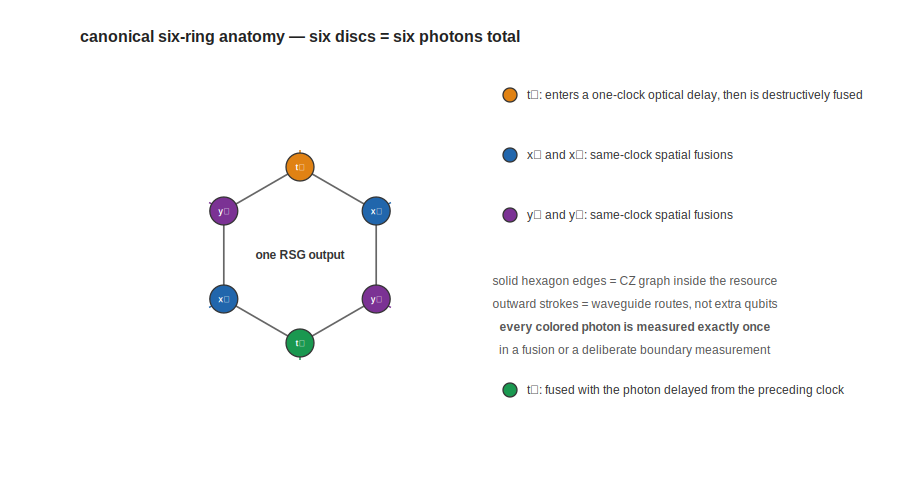

In [5]:
show_svg(canon_diagramA())

**Why four spatial and two temporal ports?** It is an architectural slicing of the rotated cubic network. A ring/cell has six face-neighbours. Choosing one cubic direction as physical time makes four faces spatial and two temporal. Four photons can enter fusion devices immediately; one temporal photon arrives from the previous delay and one is delayed to the next cycle.

The original node-plus-leaf picture doubled these objects. Here the distinction is instead:

- **graph vertex / photon:** the coloured disc, a physical dual-rail qubit;
- **routing half-edge:** a waveguide path ending at a fusion device;
- **syndrome-graph edge:** one classical $m_{XX}$ or $m_{ZZ}$ outcome after detection.

Those are three descriptions of different things, not three photons.

In [6]:
ports=[:tm,:yp,:xp,:tp,:ym,:xm]
dest=Dict(:xp=>"same-clock +x fusion",:xm=>"same-clock -x fusion",
          :yp=>"same-clock +y fusion",:ym=>"same-clock -y fusion",
          :tm=>"fusion with preceding delayed photon",:tp=>"delay, then next-clock fusion")
println("six photons, six destinations, one destructive measurement each:")
for (i,p) in enumerate(ports); println("  q$i = ",rpad(string(p),3),"  →  ",dest[p]); end
println("unique ports = ",length(unique(ports))," · hidden leaves = 0")

six photons, six destinations, one destructive measurement each:
  q1 = tm   →  fusion with preceding delayed photon
  q2 = yp   →  same-clock +y fusion
  q3 = xp   →  same-clock +x fusion
  q4 = tp   →  delay, then next-clock fusion
  q5 = ym   →  same-clock -y fusion
  q6 = xm   →  same-clock -x fusion
unique ports = 6 · hidden leaves = 0


### The $d{=}3$ fit, and the primal/dual rhythm

The rotated planar $d=3$ code still has nine data qubits, four $X$ stabilizers, four $Z$ stabilizers, and one logical qubit. But **nine data qubits do not imply nine rings total**. Repeated QEC is a 3-D spacetime object. Rings tile the cells of that 3-D fusion complex; code distance is the minimum non-trivial correlation path or membrane between the appropriate boundaries.

Primal and dual information is simultaneous. Every successful fusion reports both $m_{XX}$ and $m_{ZZ}$, one outcome for each syndrome component. There is no required odd-$Z$/even-$X$ alternation and no automatic Hadamard applied to a named data worldline once per slab.

In [7]:
const SURF_X=Dict("X2356"=>[2,3,5,6],"X4578"=>[4,5,7,8],"X12"=>[1,2],"X89"=>[8,9])
const SURF_Z=Dict("Z1245"=>[1,2,4,5],"Z5689"=>[5,6,8,9],"Z47"=>[4,7],"Z36"=>[3,6])
const SURF_ZL=[1,2,3]; const SURF_XL=[1,4,7]
commutes(A,B)=iseven(length(intersect(A,B)))
println("all rotated-code X/Z checks commute: ",all(commutes(x,z) for x in values(SURF_X) for z in values(SURF_Z)))
println("logical representatives ZL=",SURF_ZL," and XL=",SURF_XL," anticommute: ",!commutes(SURF_ZL,SURF_XL))
L=3; nspatial=2L*(L-1); temporal=L^2; boundaryZ=4L
println("open 3×3 steady-state slice: 9 rings = 54 new photons")
println("  ",nspatial," spatial fusions + ",temporal," incoming temporal fusions + ",boundaryZ," boundary-Z measurements")
println("  ",L^2," t⁺ photons enter delay; every one is consumed in the next slice")

all rotated-code X/Z checks commute: true


logical representatives ZL=[1, 2, 3] and XL=[1, 4, 7] anticommute: true
open 3×3 steady-state slice: 9 rings = 54 new photons
  12 spatial fusions + 9 incoming temporal fusions + 12 boundary-Z measurements
  9 t⁺ photons enter delay; every one is consumed in the next slice


### The patch, ring by ring — the fusion graph is *local*

Rings are numbered row-major: $r_1,r_2,r_3$ across the top, then $r_4,r_5,r_6$, then $r_7,r_8,r_9$. Every blue link is one destructive Bell fusion and returns the pair $(M_{XX},M_{ZZ})\in\{+1,-1\}^2$, or equivalently the bits

$$m_d^x(\mathbf c)=\frac{1-M_{XX}[F_d(\mathbf c)]}{2},\qquad m_d^z(\mathbf c)=\frac{1-M_{ZZ}[F_d(\mathbf c)]}{2}.$$

Here $F_d(\mathbf c)$ fuses the $+d$ photon of the ring at cubic coordinate $\mathbf c$ with the $-d$ photon of the ring at $\mathbf c+\hat d$. The figure shows the $d=x,y$ links in one clock slice; $d=t$ links join neighbouring slices. Its ledger spells out both photon endpoints—for example, $F_{x1}$ consumes $r_1{:}x^+$ and $r_2{:}x^-$, while $F_{y1}$ consumes $r_1{:}y^+$ and $r_4{:}y^-$.

With the ring order $(t^-,y^+,x^+,t^+,y^-,x^-)$, one translated bulk-check bit is

$$\begin{aligned}
s(\mathbf c)={}&m_x^x(\mathbf c)\oplus m_y^z(\mathbf c)\oplus m_t^z(\mathbf c)\\
&\oplus m_x^z(\mathbf c+\hat t)\oplus m_y^x(\mathbf c+\hat t)\\
&\oplus m_x^z(\mathbf c+\hat y)\oplus m_t^x(\mathbf c+\hat y)\oplus m_x^x(\mathbf c+\hat y+\hat t)\\
&\oplus m_y^x(\mathbf c+\hat x)\oplus m_t^x(\mathbf c+\hat x)\\
&\oplus m_y^z(\mathbf c+\hat x+\hat t)\oplus m_t^z(\mathbf c+\hat x+\hat y)\pmod2 .
\end{aligned}$$

Thus $C(\mathbf c)=(-1)^{s(\mathbf c)}$ is the measured check eigenvalue: a clean check has $s=0$ and a fired check has $s=1$. It contains six $m^x$ ($M_{XX}$) records and six $m^z$ ($M_{ZZ}$) records, from spatial **and temporal** fusions. The mixing is forced by each ring stabilizer $K_i=X_iZ_{i-1}Z_{i+1}$.

The two syndrome graphs are instead the two checkerboard classes $\chi(\mathbf c)=(c_x+c_y+c_t)\bmod2$: call $\chi=0$ primal and $\chi=1$ dual (or swap the names). Both classes use the same translated mixed formula. Which class is described as detecting $X$ or $Z$ faults is a convention; it is **not** selected by taking only the $M_{XX}$ or only the $M_{ZZ}$ channel.

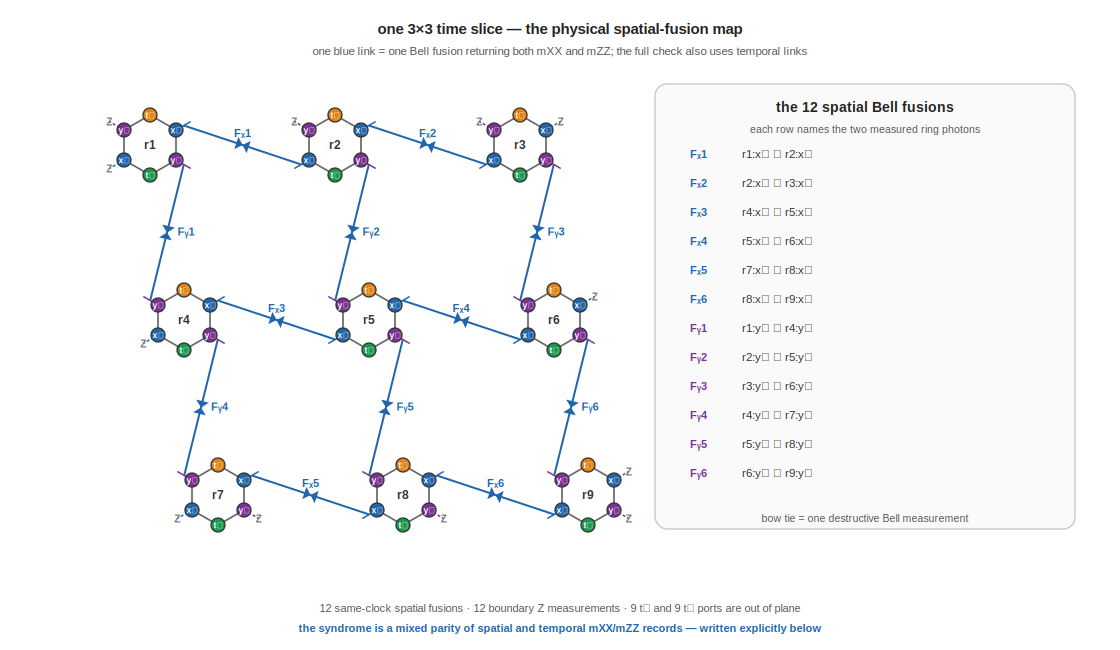

In [8]:
show_svg(canon_diagramB(:hardware))

In [9]:
const BASE_CHECK=[
 ((0,0,0),:x,:x),((0,0,0),:y,:z),((0,0,0),:t,:z),
 ((0,0,1),:x,:z),((0,0,1),:y,:x),
 ((0,1,0),:x,:z),((0,1,0),:t,:x),((0,1,1),:x,:x),
 ((1,0,0),:y,:x),((1,0,0),:t,:x),
 ((1,0,1),:y,:z),((1,1,0),:t,:z)]
println("one check s(c) is the XOR of these fusion-record bits:")
for (off,d,p) in BASE_CHECK
    @printf("  %-3s from F_%s at c + (%d,%d,%d)\n",p==:x ? "mXX" : "mZZ",d,off[1],off[2],off[3])
end
println("totals: ",count(q->q[3]==:x,BASE_CHECK)," mXX + ",count(q->q[3]==:z,BASE_CHECK)," mZZ")
println("cell parity χ(c)=(cₓ+cᵧ+cₜ) mod 2 chooses the primal/dual checkerboard")

one check s(c) is the XOR of these fusion-record bits:
  mXX from F_x at c + (0,0,0)
  mZZ from F_y at c + (0,0,0)


  mZZ from F_t at c + (0,0,0)
  mZZ from F_x at c + (0,0,1)
  mXX from F_y at c + (0,0,1)
  mZZ from F_x at c + (0,1,0)
  mXX from F_t at c + (0,1,0)
  mXX from F_x at c + (0,1,1)
  mXX from F_y at c + (1,0,0)
  mXX from F_t at c + (1,0,0)
  mZZ from F_y at c + (1,0,1)
  mZZ from F_t at c + (1,1,0)
totals: 6 mXX + 6 mZZ
cell parity χ(c)=(cₓ+cᵧ+cₜ) mod 2 chooses the primal/dual checkerboard


### Which spatial photons meet in the 12 fusions?

There are six $x$-links and six $y$-links in an open $3\times3$ grid:

$$r_{(a,b)}{:}x^+ \bowtie r_{(a+1,b)}{:}x^-,\qquad r_{(a,b)}{:}y^+ \bowtie r_{(a,b+1)}{:}y^-.$$

Thus each interior spatial photon has exactly one partner. The twelve outward-facing ports have no in-slice neighbour: $x^-$ on the left edge, $x^+$ on the right, $y^-$ on the top, and $y^+$ on the bottom. In this teaching boundary they receive single-photon $Z$ measurements. The $t^-$ and $t^+$ photons are separate temporal ports and are not counted among these twelve spatial fusions.

The ring labels $r_i$ label **resource states / cubic cells**, not the nine data-qubit labels $d_i$ used in the separate rotated-code algebra. Consequently, expressions such as the old ‘$(1,4)$ fusion’ mixed two descriptions: $r_1{:}y^+\bowtie r_4{:}y^-$ is a real hardware fusion, but it is not a direct measurement of the surface-code operator $Z_1Z_4$ on data qubits.

Also keep two different counts apart: this drawing contains **12 physical spatial fusions**, each returning two bits; one bulk topological **cell check** is a parity of **12 outcome bits**—six $XX$ and six $ZZ$—collected from neighbouring fusions in spacetime. The formula above states the check explicitly; Section 8 verifies that it lies in $\mathcal R\cap\mathcal F$ and tests every translated check.

In [10]:
spatial_links=canon_spatial_links()
println("ID    first measured photon    second measured photon")
println("──    ─────────────────────    ──────────────────────")
for (fid,a,sa,b,sb) in spatial_links
    @printf("%-4s  r%d:%-3s                    r%d:%-3s\n",fid,a,CANON_PORTLAB[sa],b,CANON_PORTLAB[sb])
end
endpoints=reduce(vcat, [[(a,sa),(b,sb)] for (_,a,sa,b,sb) in spatial_links])
boundary_ports=[(i,k) for i in 1:9 for k in (2,3,5,6) if !((i,k) in endpoints)]
println("\nspatial fusions = ",length(spatial_links)," · fused spatial photons = ",length(unique(endpoints)))
println("unpaired in-slice spatial ports = ",length(boundary_ports)," (the boundary-Z ports)")
println("every fused endpoint used exactly once: ",length(endpoints)==length(unique(endpoints)))

ID    first measured photon    second measured photon
──    ─────────────────────    ──────────────────────
Fₓ1   r1:x⁺                     r2:x⁻ 
Fₓ2   r2:x⁺                     r3:x⁻ 


Fₓ3   r4:x⁺                     r5:x⁻ 
Fₓ4   r5:x⁺                     r6:x⁻ 
Fₓ5   r7:x⁺                     r8:x⁻ 
Fₓ6   r8:x⁺                     r9:x⁻ 
Fᵧ1   r1:y⁺                     r4:y⁻ 
Fᵧ2   r2:y⁺                     r5:y⁻ 
Fᵧ3   r3:y⁺                     r6:y⁻ 
Fᵧ4   r4:y⁺                     r7:y⁻ 
Fᵧ5   r5:y⁺                     r8:y⁻ 
Fᵧ6   r6:y⁺                     r9:y⁻ 

spatial fusions = 12

 · fused spatial photons = 24
unpaired in-slice spatial ports = 12 (the boundary-Z ports)
every fused endpoint used exactly once: true


## 5 · How rings tile space and time — and the references

Two equivalent descriptions from the primary literature are useful:

- **Body-centred cubic description.** Two ring resources occupy opposite corners of a unit cell. Fusion photons meet on faces and edges. Each cell check contains six face-$XX$ and six link-$ZZ$ outcomes.
- **Rotated cubic description.** Every cubic cell corresponds to one ring and its six photons fuse across the six faces to six neighbouring cells. Every cubic vertex is a check; vertices are two-colourable into primal and dual components.
- **Hardware time slicing.** Choose a cubic direction as clock time. Four ports fuse in the current slice and two connect successive emissions using a delay. This schedules the same fusion graph; it does not add a physical time meaning to an individual logical data qubit.

References: Bartolucci *et al.*, [Fusion-based quantum computation](https://www.nature.com/articles/s41467-023-36493-1) and its Supplementary Notes V B–C; Bombín *et al.*, [Interleaving](https://arxiv.org/abs/2103.08612); Raussendorf–Harrington–Goyal, [topological cluster-state QEC](https://doi.org/10.1088/1367-2630/9/6/199).

**Space and time in one picture.** Follow the hardware path, not a persistent data photon. A $t^+$ photon from one ring is delayed and Bell-fused with the $t^-$ photon of a later ring. Both disappear at that measurement. The resulting two classical bits are edges in the 3-D syndrome graphs.

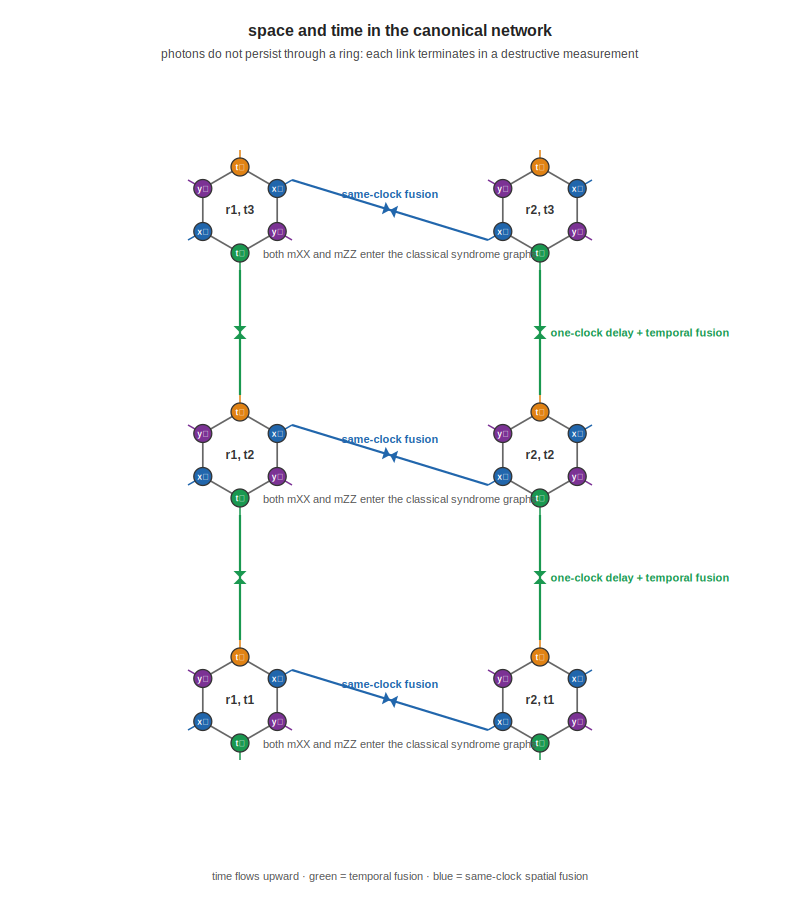

In [11]:
show_svg(canon_diagramC())

And the whole $3\times3$ teaching slice, three clocks deep. Blue/purple links are same-clock spatial fusions and green links are delayed temporal fusions. A genuine planar logical memory additionally specifies primal/dual side boundaries plus initialization and readout caps; the diagram intentionally shows the bulk connectivity before all cap details are chosen.

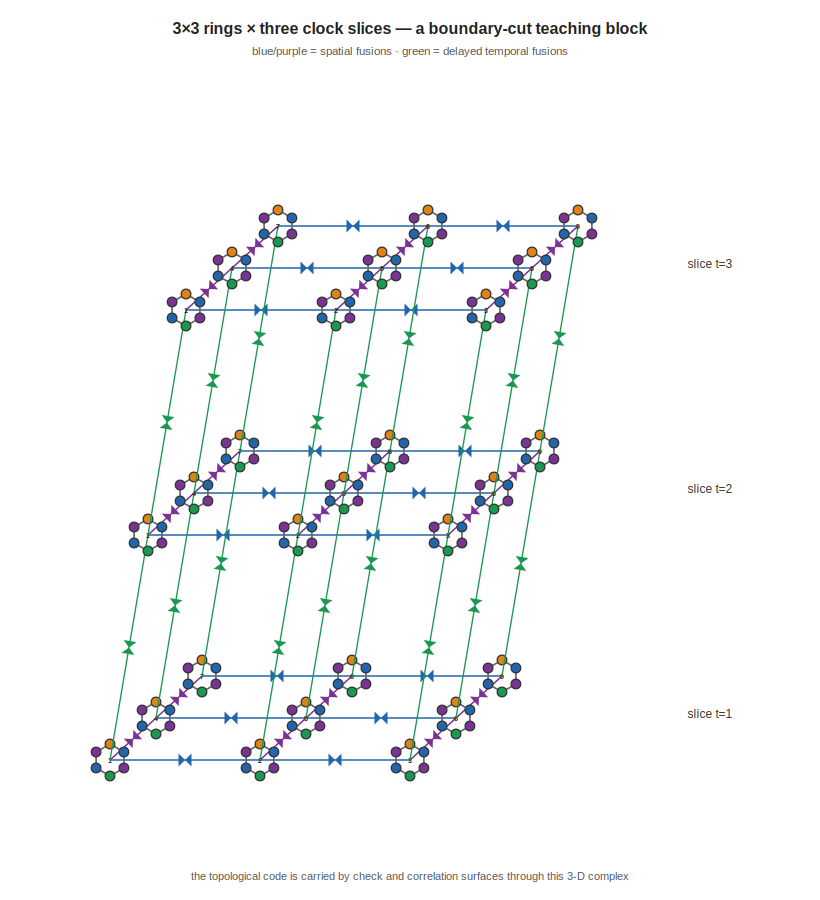

In [12]:
show_svg(canon_diagramC2())

## 6 · The machine — resource boxes and the slab

Below is the whole machine again, in the deliberately explicit style of the original notebook. The discipline to watch for is now the canonical one:

* `prep_ring!` is the **resource box**—the only place a ring CZ appears. One call emits exactly six photons and no leaves;
* `slab!` prepares the nine rings of one $3\times3$ clock slice, performs the twelve in-slice spatial Bell fusions, joins the nine incoming temporal photons when a previous slice exists, and $Z$-measures the deliberately cut boundary ports;
* the nine $t^+$ photons are the only quantum objects retained at the end of a non-final slab. They wait in a one-clock delay and are consumed by the next slab's $t^-$ fusions; and
* every fusion files its two click parities under a coordinate-based name in `rec`. Syndrome extraction and decoding happen only after the record exists.

The executable experiment uses two $3\times3$ slices. This is the smallest block matching the diagram above that contains four complete 12-outcome bulk checks. It is a detector block, not yet a finite logical surface-code memory with all four boundary types and logical caps.

In [13]:
PEAK = Ref(0); track!(r) = (PEAK[] = max(PEAK[], length(r)))
nname(t,i,k) = Symbol("t$(t)_r$(i)_q$(k)")       # photon k of ring i, clock slice t
ringcoord(i,t) = ((i-1)%3, (i-1)÷3, t-1)          # r1,r2,r3 / r4,r5,r6 / r7,r8,r9
edgekey(c,d,p) = "f_$(c[1])_$(c[2])_$(c[3])_$(d)_$(p)"  # one fusion-outcome bit
spatial(t) = canon_spatial_links()                 # the same 12 links that draw diagram B

# ══ RESOURCE BOX · the canonical six-photon ring ══════════════════════════
# Everything in here is what the SOURCE emits, already entangled. There are
# exactly six |+> photons and six internal CZ edges—no node/leaf doubling.
function prep_ring!(r::Reg, t, i)
    q = [nname(t,i,k) for k in 1:6]
    ring_resource_state!(r, q)                    # q1–q2–q3–q4–q5–q6–q1
    track!(r)
    return q
end

# ══ ONE PAID FUSION · photons disappear, two classical bits remain ═════════
# A requested physical fault is inserted immediately before this Bell
# measurement: Z flips its mXX result; X flips its mZZ result. This lets the
# exact MPS generate—not merely post-edit—the faulty fusion record.
function record_fusion!(r::Reg, rec, c, d, a, b; errkey=nothing)
    kx=edgekey(c,d,:x); kz=edgekey(c,d,:z)
    errkey==kx && z!(r,a)                         # Z_a anticommutes with X_aX_b
    errkey==kz && x!(r,a)                         # X_a anticommutes with Z_aZ_b
    mx,mz=fuse!(r,a,b)                            # both photons are measured and dropped
    rec[kx]=mx; rec[kz]=mz
    return nothing
end

# ══ THE SLAB · deliver nine rings, fuse their four spatial directions ═══════
# `delayed` contains only q4=t+ photons from the preceding slab. In the first
# slab there is no predecessor, so q1=t- is closed by the chosen Z input cap.
function slab!(r::Reg, t, delayed, rec::Dict{String,Int}; errkey=nothing)
    # ─ STEP 1 · DELIVER ─ nine independent six-ring resources.
    for i in 1:9
        prep_ring!(r,t,i)
    end

    # ─ STEP 2 · TEMPORAL FUSIONS ─ previous q4=t+ meets current q1=t-.
    if t==1
        for i in 1:9
            rec["cap_in_t$(t)_r$(i)_z"] = measdrop!(r,nname(t,i,1),'Z')
        end
    else
        for i in 1:9
            c=ringcoord(i,t-1)                    # the edge begins in slice t-1
            record_fusion!(r,rec,c,:t,delayed[i],nname(t,i,1);errkey=errkey)
        end
    end

    # ─ STEP 3 · SPATIAL FUSIONS ─ x+:x- and y+:y- on the 12 blue links.
    # Each bulk ring offers q2,q3,q5,q6. At this open boundary an outward port
    # has no partner and will be Z-measured in step 4.
    used=Set{Tuple{Int,Int}}()
    for (_,a,sa,b,sb) in spatial(t)
        push!(used,(a,sa)); push!(used,(b,sb))
        d=sa==3 ? :x : :y
        record_fusion!(r,rec,ringcoord(a,t),d,nname(t,a,sa),nname(t,b,sb);errkey=errkey)
    end

    # ─ STEP 4 · SIDE BOUNDARY ─ replace only the missing outward fusions by Z.
    # This is boundary carving, not a permanent pad/prune role of a ring site.
    for i in 1:9, k in (2,3,5,6)
        if !((i,k) in used)
            rec["boundary_t$(t)_r$(i)_q$(k)_z"] = measdrop!(r,nname(t,i,k),'Z')
        end
    end

    # ─ STEP 5 · DELAY ─ only q4=t+ survives this function call. It is not a
    # logical data node; the next slab consumes it in a temporal fusion.
    track!(r)
    return [nname(t,i,4) for i in 1:9]
end

# ══ A TWO-SLICE EXACT-MPS DETECTOR RUN ═══════════════════════════════════════
function run_memory(nslabs=2; errkey=nothing, recordflip=nothing, show=false)
    r=Reg(); rec=Dict{String,Int}(); delayed=Symbol[]
    PEAK[]=0; reset_fuses!(); SHOW_FUSIONS[]=show
    for t in 1:nslabs
        delayed=slab!(r,t,delayed,rec;errkey=errkey)
    end
    SHOW_FUSIONS[]=false
    for i in 1:9                                   # chosen final Z cap: consume q4=t+
        rec["cap_out_t$(nslabs)_r$(i)_z"] = measdrop!(r,delayed[i],'Z')
    end
    recordflip!==nothing && (rec[recordflip] ⊻= 1) # optional classical record corruption
    @assert length(r)==0                           # all 108 emitted photons were consumed
    return rec
end
println("ring-native ITensor machine defined · six photons per ring · no leaves or surviving nodes")

ring-native ITensor machine defined · six photons per ring · no leaves or surviving nodes


### The life of one ring — emit, route, fuse, replace

Read the lifecycle diagram against `slab!`: source, route, measure, record. The only object retained between calls is the $t^+$ photon in the optical delay. It survives for one clock because its scheduled Bell partner has not been emitted yet—not because it is a data node.

There is therefore no pad/retire machinery. A side-boundary photon is simply measured in $Z$ instead of entering a missing fusion. Once the next ring arrives, the delayed $t^+$ photon and the new $t^-$ photon are both destroyed and their $(m_{XX},m_{ZZ})$ bits join `rec`.

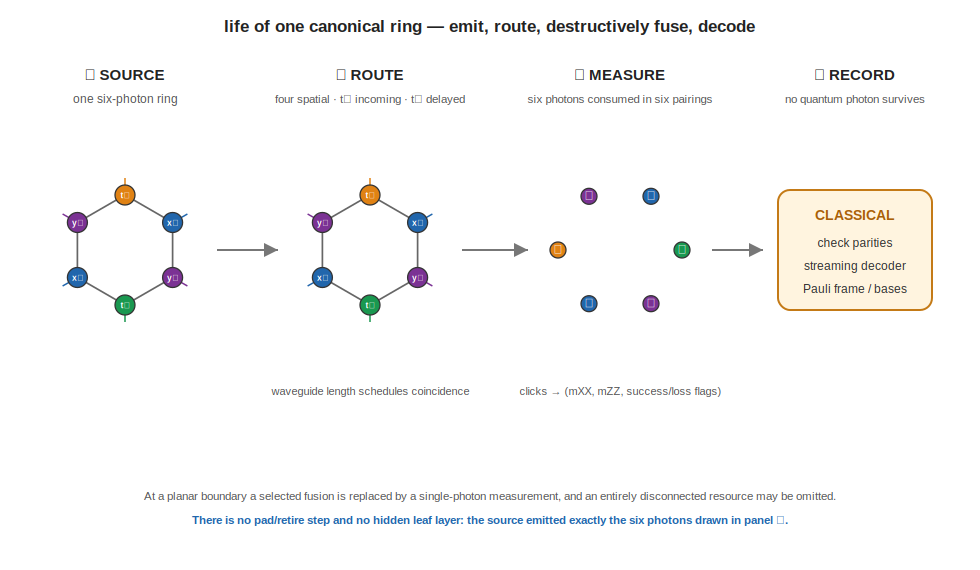

In [14]:
show_svg(canon_diagramD())

## 7 · One slab, shown — the exact beam-splitter measurements

Run the actual dynamic-site ITensor MPS. Slice 1 has twelve spatial fusions and leaves nine $t^+$ photons in delay. Slice 2 pays nine temporal plus twelve spatial fusions. The complete two-slice block therefore contains **33 physical Bell measurements**, 66 Bell-outcome bits, and 42 cap/boundary $Z$ outcomes.

`SHOW_FUSIONS` prints every destructive pairing. The register reaches 63 photons only briefly—nine delayed photons plus the 54 photons emitted in the next slice—and is empty after the output cap.

In [15]:
Random.seed!(31)
REC_MPS = run_memory(2; show=true)
println("\nfusions in two slices = ",FUSES[],"   ·   peak register = ",PEAK[]," photons")
println("emitted photons = ",2*9*6,"   ·   fusion bits = ",2FUSES[],"   ·   complete record bits = ",length(REC_MPS))

    beam-splitter fusion t1_r1_q3

⋈t1_r2_q6  →  Bell outcome Φ⁺   (X₁X₂=1, Z₁Z₂=1)
    beam-splitter fusion t1_r2_q3⋈t1_r3_q6  →  Bell outcome Ψ⁻   (X₁X₂=-1, Z₁Z₂=-1)
    beam-splitter fusion t1_r4_q3⋈t1_r5_q6  →  Bell outcome Φ⁻   (X₁X₂=-1, Z₁Z₂=1)
    beam-splitter fusion t1_r5_q3⋈t1_r6_q6  →  Bell outcome Φ⁺   (X₁X₂=1, Z₁Z₂=1)
    beam-splitter fusion t1_r7_q3⋈t1_r8_q6  →  Bell outcome Φ⁻   (X₁X₂=-1, Z₁Z₂=1)
    beam-splitter fusion t1_r8_q3⋈t1_r9_q6  →  Bell outcome Φ⁺   (X₁X₂=1, Z₁Z₂=1)
    beam-splitter fusion t1_r1_q2⋈t1_r4_q5  →  Bell outcome Ψ⁻   (X₁X₂=-1, Z₁Z₂=-1)
    beam-splitter fusion t1_r2_q2⋈t1_r5_q5  →  Bell outcome Ψ⁺   (X₁X₂=1, Z₁Z₂=-1)
    beam-splitter fusion t1_r3_q2

⋈t1_r6_q5  →  Bell outcome Φ⁻   (X₁X₂=-1, Z₁Z₂=1)
    beam-splitter fusion t1_r4_q2⋈t1_r7_q5  →  Bell outcome Ψ⁺   (X₁X₂=1, Z₁Z₂=-1)


    beam-splitter fusion t1_r5_q2⋈t1_r8_q5  →  Bell outcome Ψ⁻   (X₁X₂=-1, Z₁Z₂=-1)
    beam-splitter fusion t1_r6_q2⋈t1_r9_q5  →  Bell outcome Ψ⁻   (X₁X₂=-1

, Z₁Z₂=-1)
    beam-splitter fusion t1_r1_q4

...

⋈t2_r4_q5  →  Bell outcome Φ⁺   (X₁X₂=1, Z₁Z₂=1)
    beam-splitter fusion t2_r2_q2

⋈t2_r5_q5  →  Bell outcome Φ⁻   (X₁X₂=-1, Z₁Z₂=1)
    beam-splitter fusion t2_r3_q2⋈t2_r6_q5  →  Bell outcome Φ⁺   (X₁X₂=1, Z₁Z₂=1)
    beam-splitter fusion t2_r4_q2

⋈t2_r7_q5  →  Bell outcome Φ⁻   (X₁X₂=-1, Z₁Z₂=1)
    beam-splitter fusion t2_r5_q2⋈t2_r8_q5  →  Bell outcome Ψ⁺   (X₁X₂=1, Z₁Z₂=-1)
    beam-splitter fusion t2_r6_q2⋈t2_r9_q5  →  Bell outcome Ψ⁻   (X₁X₂=-1

, Z₁Z₂=-1)

fusions in two slices = 33   ·   peak register = 63 photons
emitted photons = 108   ·   fusion bits = 66

   ·   complete record bits = 108


## 8 · The syndrome is *in the record* — detectors as parity products

No photon is ever read out as ‘the syndrome’. The machine produces only `rec`: every fusion's $(m_{XX},m_{ZZ})$ clicks plus the explicitly named cap measurements. The four complete checks inside this open $3\times3\times2$ block are fixed parities of the **fusion** portion of that record.

The compositions below are translations of the 12-term $\mathcal R\cap\mathcal F$ seed written in §4; they were not fitted from clean samples. Each contains six $m_{XX}$ and six $m_{ZZ}$ values spread over the two slices. A clean ITensor branch can make the individual clicks look random, but their prescribed XOR must be zero.

In [16]:
addc(a,b)=(a[1]+b[1],a[2]+b[2],a[3]+b[3])
checkspec(c)=[edgekey(addc(c,off),d,p) for (off,d,p) in BASE_CHECK]
checkname(c)="c_$(c[1])_$(c[2])_$(c[3])"

# Independent stabilizer proof of the seed check: multiply the listed ring
# generators K_i=X_i Z_{i-1} Z_{i+1}, then multiply the twelve measured
# fusion observables. Their binary X/Z supports must be identical.
const POS_SLOT=Dict(:x=>3,:y=>2,:t=>4); const NEG_SLOT=Dict(:x=>6,:y=>5,:t=>1)
const DELTA=Dict(:x=>(1,0,0),:y=>(0,1,0),:t=>(0,0,1))
const BASE_K=[((0,0,0),3),((0,0,1),2),((0,1,0),4),((0,1,1),1),
 ((0,1,1),3),((0,1,1),5),((1,0,0),2),((1,0,0),4),((1,0,0),6),
 ((1,0,1),1),((1,1,0),5),((1,1,1),6)]
toggle!(s,k)=(k in s ? delete!(s,k) : push!(s,k); s)
rx=Set(); rz=Set(); fx=Set(); fz=Set()
for (c,k) in BASE_K
    toggle!(rx,(c,k)); toggle!(rz,(c,k==1 ? 6 : k-1)); toggle!(rz,(c,k==6 ? 1 : k+1))
end
for (c,d,p) in BASE_CHECK
    target=p==:x ? fx : fz; nb=addc(c,DELTA[d])
    toggle!(target,(c,POS_SLOT[d])); toggle!(target,(nb,NEG_SLOT[d]))
end
println("explicit R∩F support identity: ",(rx==fx)&&(rz==fz))

# Four 2×2×2 cells fit inside 3×3 spatial rings × two clock slices.
# The original notebook stored each detector as (constant, record-bit names),
# so we keep that useful representation here.
const DET2=Dict(checkname((x,y,0)) => (0,checkspec((x,y,0))) for x in 0:1 for y in 0:1)
detbit(rec,d)=reduce(⊻,(rec[k] for k in d[2]);init=d[1])
cellnames=sort(collect(keys(DET2)))
syndrome(rec)=[c for c in cellnames if detbit(rec,DET2[c])==1]

# Build the small detector graph directly from the written check formulas.
FUSION_KEYS=sort(unique(vcat([d[2] for d in values(DET2)]...)))
INCIDENCE=Dict(k=>sort([c for c in cellnames if k in DET2[c][2]]) for k in FUSION_KEYS)
for c in cellnames
    ks=DET2[c][2]
    println(c,": ",length(ks)," fusion bits = ",count(endswith("_x"),ks)," mXX + ",count(endswith("_z"),ks)," mZZ")
end
println("clean exact-MPS syndrome = ",syndrome(REC_MPS))

explicit R∩F support identity: true


c_0_0_0

: 12 fusion bits = 6 mXX + 6 mZZ
c_0_1_0: 12 fusion bits = 6 mXX + 6 mZZ
c_1_0_0: 12 fusion bits = 6 mXX + 6 mZZ
c_1_1_0: 12 fusion bits = 6 mXX + 6 mZZ
clean exact-MPS syndrome = 

String[]


### Anatomy of one detector — from the $(m_x, m_z)$ clicks to a syndrome bit

Walk one detector all the way from click record to syndrome. `f_0_0_0_x_x` means: the fusion rooted at cubic coordinate $(0,0,0)$ in the $+x$ direction, and its $m_{XX}$ output. Replacing the final `_x` by `_z` addresses the $m_{ZZ}$ output of that **same** Bell measurement.

`c_0_0_0` selects the twelve keys printed below and XORs their actual ITensor outcomes. The equivalent eigenvalue product is $C_{000}=\prod_j(-1)^{m_j}=(-1)^{\oplus_jm_j}$. The result is $+1$ precisely when the printed syndrome bit is zero. Neither the six `mXX` keys nor the six `mZZ` keys alone is the ring-network check.

In [17]:
C000=DET2["c_0_0_0"]
println("record key                    bit    eigenvalue")
println("──────────────────────────    ───    ──────────")
for k in C000[2]
    @printf("%-29s %d       %+d\n",k,REC_MPS[k],(-1)^REC_MPS[k])
end
s000=detbit(REC_MPS,C000)
println("\nXOR of the twelve bits = ",s000)
println("product of the twelve eigenvalues = ",(-1)^s000,"   ← clean check")

record key                    bit    eigenvalue
──────────────────────────    ───    ──────────
f_0_0_0_x_x                   0       +1
f_0_0_0_y_z                   1       -1


f_0_0_0_t_z                   0       +1
f_0_0_1_x_z                   0       +1
f_0_0_1_y_x                   0       +1
f_0_1_0_x_z                   0       +1
f_0_1_0_t_x                   0       +1
f_0_1_1_x_x                   0       +1
f_1_0_0_y_x                   0       +1
f_1_0_0_t_x                   1       -1
f_1_0_1_y_z                   0       +1
f_1_1_0_t_z                   0       +1

XOR of the twelve bits = 0
product of the twelve eigenvalues = 1   ← clean check


**Live check on the exact ITensor record.** First confirm that all four prescribed parities are silent. Then flip each fusion-record bit in turn—purely as a classical detector-error experiment—and verify that the fired checks are exactly the check nodes incident on that outcome edge. This is the detector error model that the decoder will invert.

In [18]:
@assert isempty(syndrome(REC_MPS))
edge_ok=true
for k in FUSION_KEYS
    r=copy(REC_MPS); r[k]⊻=1
    edge_ok &= syndrome(r)==INCIDENCE[k]
end
TARGET_KEY=first(k for k in FUSION_KEYS if length(INCIDENCE[k])==2 && endswith(k,"_x"))
TARGET_ZKEY=first(k for k in FUSION_KEYS if length(INCIDENCE[k])==2 && endswith(k,"_z"))
println("all four exact-MPS checks silent: ",isempty(syndrome(REC_MPS)))
println("every single record flip fires exactly its incident checks: ",edge_ok)
println("example mXX edge: ",TARGET_KEY," → ",INCIDENCE[TARGET_KEY])
println("example mZZ edge: ",TARGET_ZKEY," → ",INCIDENCE[TARGET_ZKEY])

all four exact-MPS checks silent: true


every single record flip fires exactly its incident checks: true
example mXX edge: f_1_1_0_t_x → ["c_0_1_0", "c_1_0_0"]
example mZZ edge: f_1_1_0_t_z → ["c_0_0_0", "c_1_1_0"]


## 9 · The detector experiment — on the exact MPS

Now follow the same four-example rhythm as the original notebook, but entirely at the level this finite block genuinely implements. A clean exact-MPS run gives four silent cell checks. A corruption of one recorded Bell outcome fires the adjacent checks. The corresponding **physical Pauli inserted before that fusion** produces the same syndrome on a second exact-MPS run. Finally the decoder consumes only the fired-check list and restores a syndrome-consistent record.

This is deliberately called a detector experiment rather than a demonstrated logical memory: the $3\times3\times2$ block has input/output $Z$ caps chosen to close the local cells, but it does not yet contain the complete rough/smooth planar boundary construction or a logical correlation surface. We can therefore verify syndrome extraction and record decoding exactly without inventing a logical readout that the block does not encode.

### [1] Clean run — four silent detectors from the real fusion clicks

The individual $m_{XX}$ and $m_{ZZ}$ values in `REC_MPS` are random measurement results. Only the four prescribed 12-bit parities are fixed. This is precisely what the classical processor receives after the photons have disappeared.

In [19]:
println("detectors: ",join(["$c=$(detbit(REC_MPS,DET2[c]))" for c in cellnames],"  "))
println("syndrome = {",join(syndrome(REC_MPS),", "),"}")
println("peak register = ",PEAK[]," photons   ·   all photons remaining after caps = 0")

detectors: c_0_0_0=0  c_0_1_0=0  c_1_0_0=0  c_1_1_0=0


syndrome = {}
peak register = 63 photons   ·   all photons remaining after caps = 0


### [2] Flip one recorded $m_{XX}$ value — its incident checks fire

First model a detector/readout error at the classical interface: copy the genuine ITensor record and toggle `TARGET_KEY`. The two fired checks are not guessed from the sampled values; they are the two detector nodes whose formulas contain that fusion-outcome edge.

In [20]:
REC_CLASSICAL=copy(REC_MPS); REC_CLASSICAL[TARGET_KEY]⊻=1
println("flipped record bit: ",TARGET_KEY)
println("predicted incident checks: ",INCIDENCE[TARGET_KEY])
println("syndrome read from rec:   ",syndrome(REC_CLASSICAL))

flipped record bit: f_1_1_0_t_x
predicted incident checks: ["c_0_1_0", "c_1_0_0"]
syndrome read from rec:   ["c_0_1_0", "c_1_0_0"]


### [3] A physical $Z$ before that fusion — ITensor produces the same syndrome

Now generate a fresh exact-MPS branch and insert $Z$ on the first photon immediately before the Bell measurement represented by `TARGET_KEY`. Because $Z_a$ anticommutes with $X_aX_b$ but commutes with $Z_aZ_b$, it flips precisely that fusion's $m_{XX}$ channel. The individual random clicks differ from the clean run, but the syndrome signature must be identical.

In [21]:
Random.seed!(33)
REC_PHYSICAL=run_memory(2;errkey=TARGET_KEY)
println("physical fault targets: ",TARGET_KEY)
println("expected syndrome:       ",INCIDENCE[TARGET_KEY])
println("exact-MPS syndrome:      ",syndrome(REC_PHYSICAL))

physical fault targets: f_1_1_0_t_x


expected syndrome:       ["c_0_1_0", "c_1_0_0"]
exact-MPS syndrome:      ["c_0_1_0", "c_1_0_0"]


### [4] Quantum fault and classical record fault — the decoder sees the same thing

The decoder never sees the injected Pauli or the photon labels. It receives the four syndrome bits. Both mechanisms above produce the same two defects, so they belong to the same edge-error hypothesis in this detector model. The photons are already gone; recovery will mean updating a classical record/frame hypothesis, not applying a gate to them.

In [22]:
println("classical corruption syndrome = ",syndrome(REC_CLASSICAL))
println("physical Pauli syndrome      = ",syndrome(REC_PHYSICAL))
println("same decoder input: ",syndrome(REC_CLASSICAL)==syndrome(REC_PHYSICAL))

classical corruption syndrome = ["c_0_1_0", "c_1

_0_0"]
physical Pauli syndrome      = ["c_0_1_0", "c_1_0_0"]
same decoder input: true


## 10 · The error sweep, and the two Bell-record channels

The original notebook used an odd/even half-layer story to alternate surface-code $Z$ and $X$ checks. The canonical record gives a simpler and directly testable structure: both Bell channels exist at every fusion, while primal/dual detector nodes occupy offset checkerboards of the 3-D network.

Sweep every fusion bit that participates in these four cells. An `_x` key is an $m_{XX}$ record and an `_z` key is the companion $m_{ZZ}$ record. Toggling either key fires exactly the checks listed by `INCIDENCE`; open-boundary edges touch one complete check, while interior edges touch two.

In [23]:
weights=Dict(1=>0,2=>0)
for k in FUSION_KEYS
    weights[length(INCIDENCE[k])] += 1
end
println("fusion outcomes represented in the four checks: ",length(FUSION_KEYS))
println("boundary incidences (one check): ",weights[1]," · interior incidences (two checks): ",weights[2])
println("\nfirst twelve error signatures:")
for k in FUSION_KEYS[1:min(12,end)]
    println("  ",rpad(k,20)," → {",join(INCIDENCE[k],", "),"}")
end

fusion outcomes represented in the four checks: 46
boundary incidences (one check): 44 · interior incidences (two checks): 2

first twelve error signatures:
  f_0_0_0_t_z         

 → {c_0_0_0}
  f_0_0_0_x_x          → {c_0_0_0}
  f_0_0_0_y_z          → {c_0_0_0}
  f_0_0_1_x_z          → {c_0_0_0}
  f_0_0_1_y_x          → {c_0_0_0}
  f_0_1_0_t_x          → {c_0_0_0}
  f_0_1_0_t_z          → {c_0_1_0}
  f_0_1_0_x_x          → {c_0_1_0}
  f_0_1_0_x_z          → {c_0_0_0}
  f_0_1_0_y_z          → {c_0_1_0}
  f_0_1_1_x_x          → {c_0_0_0}
  f_0_1_1_x_z          → {c_0_1_0}


### The $m_{ZZ}$ channel — the companion fault sector

The companion channel is identical algebraically. An $X$ on either photon immediately before a fusion anticommutes with $Z_aZ_b$ and flips its `mZZ` record. We demonstrate the downstream processing without paying for a third large MPS branch: toggle one actual `mZZ` value already sampled by ITensor and evaluate the same check formulas.

In [24]:
REC_ZCHANNEL=copy(REC_MPS); REC_ZCHANNEL[TARGET_ZKEY]⊻=1
println("mZZ record bit: ",TARGET_ZKEY)
println("incident checks: ",INCIDENCE[TARGET_ZKEY])
println("syndrome:        ",syndrome(REC_ZCHANNEL))

mZZ record bit: f_1_1_0_t_z
incident checks: ["c_0_0_0", "c_1_1_0"]
syndrome:        ["c_0_0_0", "c_1_1_0"]


## 11 · The fusion ledger

For the executed open $3\times3\times2$ block:

- eighteen calls to `prep_ring!` emit $18\times6=108$ photons—exactly six per ring;
- 24 spatial fusions consume 48 spatial photons;
- nine temporal fusions consume the first slice's nine delayed $t^+$ photons and the second slice's nine $t^-$ photons;
- 24 outward spatial photons receive the specified side-boundary $Z$ measurements;
- nine first-slice $t^-$ photons and nine final-slice $t^+$ photons receive the chosen input/output cap measurements; and
- the final register is empty.

Thus the exact run pays **33 Bell fusions** and records 66 Bell-parity bits plus 42 boundary/cap bits. The four check syndromes use only the appropriate 48 incidences of the fusion record. No pad photons, leaf photons, persistent nodes, or post-source entangling gates were introduced.

## 12 Fusion Success is 50% failure

The ideal executions above condition on successful Bell projections. An unboosted passive-linear-optical analyzer succeeds with probability $1/2$. On failure it performs separable measurements in a known basis; multiplying those two outcomes preserves one of the intended parities and the other parity is heralded erased. Photon loss is different: in the dual-rail model it removes the event from the computational subspace and erases both parity outcomes.

QEC therefore acts on **outcome-edge erasures and flips**, not on an all-fusions-must-succeed postselection probability.

### Single failures in the network — absorbed

If a known outcome edge is absent, the two incident checks cannot be evaluated separately. Their product cancels that edge and forms a larger **supercheck**. This is the correct sense in which a heralded failure is absorbed.

It is not correct to say that a failed temporal fusion leaves a data worldline intact or that the record automatically reroutes a cut photon. The photons are still measured. Whether logical information survives is a global erasure-decoding question: the remaining check graph must contain a valid recovery/correlation surface between the chosen boundaries.

### What boosting would change here — and what it wouldn't

A Grice-style boosted analyzer with $N=2^n$ total photons has $p_{\mathrm{fail}}=2^{-n}$ and uses $2^n-2$ ancillary photons in addition to the two ring photons. The six-ring resource and its routing graph are unchanged; the ancillas live inside the fusion device.

For per-photon survival $\eta$, the probability that both intended outcomes are available is

$$P(XX\ \&\ ZZ\ \mathrm{available})=\eta^N(1-p_{\mathrm{fail}}).$$

For the randomized failure-basis model used in the threshold mapping, the erasure probability of one specified outcome channel is

$$p_0=1-(1-p_{\mathrm{fail}}/2)\eta^N.$$

This per-outcome $p_0$—not the probability that the entire Bell analyzer is fully successful—is compared with the hardware-agnostic outcome-erasure threshold.

| boost $n$ | total photons $N$ | $p_{\rm fail}$ | no-loss, per-outcome erasure $p_0=p_{\rm fail}/2$ |
|---:|---:|---:|---:|
| 1 | 2 | 50% | 25% |
| 2 | 4 | 25% | 12.5% |
| 3 | 8 | 12.5% | 6.25% |
| 4 | 16 | 6.25% | 3.125% |

With loss, increasing $N$ eventually hurts because all participating photons must arrive. The optimal boost level is therefore hardware-dependent.

### Encoded Fusion

In the $(2,2)$-Shor construction, each abstract ring qubit becomes a four-photon $[[4,1,2]]$ block. A six-ring resource therefore becomes a 24-photon encoded resource before boosting ancillas. Logical fusion observables can be reconstructed from the transversal physical outcomes and the block stabilizers.

This is **not generic majority voting**. The available logical $XX$ and $ZZ$ values depend on which physical fusions succeeded, which failure bases were used, and which photons were lost. The published 43.2% marginal fusion-failure threshold is a network-level result for that specified protocol.

### Putting it together — so is this fault tolerance?

Almost every ingredient is now on the table; here is why **both** upgrades are needed, and what
else the sentence "fault-tolerant error correction" quietly assumes. The arithmetic (numbers from
[arXiv:2101.09310](https://arxiv.org/abs/2101.09310)):

| scheme | $p_\mathrm{fail}$ achieved | threshold it must beat | verdict |
|---|---|---|---|
| raw linear optics | 50% | < 25% (bare network) | ✗ far above |
| boosting alone (1 stage) | 25% | < 25% (bare network) | ✗ sits *at* threshold — no margin |
| encoding alone, unboosted | 50% | 43.2% (encoded 6-ring) | ✗ still above, marginally |
| **encoding + 1 boost stage** | **25%** | **43.2%** | ✓ below, with margin to spare |

The *margin* in the last row matters: 43.2% is a **marginal** threshold, computed with failure as
the only noise. A real machine must sit below a threshold **surface** jointly in (fusion failure,
photon loss, Pauli error) — the margin left after failure is what gets spent on loss, the actually
hard engineering number (and why our ladder table showed boosting stops paying at $n\approx2$–$3$
for realistic $\eta$).

**Three layers of protection, at three scales:**

1. **Boosting — device level.** Reduces the *rate* of failures: $2^n\!-\!2$ ancilla photons per
   beam splitter give $p_\mathrm{fail}=2^{-n}$. Costs photons per fusion → more loss exposure.
2. **Encoding — fusion level.** Makes the failures that still happen *correctable locally*: each
   leaf → a 4-photon block, one logical fusion = 4 physical fusions, and a failed or lost physical
   fusion is an erasure fixed *inside* the logical fusion by the surviving three.
3. **Distance — network level.** Whatever leaks through both layers becomes ordinary heralded
   erasure + Pauli noise on the code, and *this* is where "below threshold" pays: logical error
   falls exponentially in $d$. Our own $d{=}3$ sweep is the cautionary tale — even at the boosted
   25% the tiny patch survived only ~33% of runs. Thresholds are asymptotic promises; the bare
   network's marginal numbers (11.98% erasure, 1.07% Pauli) are all "$d\to\infty$" statements.

So: **yes — encoded fusion with boosted beam splitters, run at sufficient distance, on a hardware
budget whose residual loss and Pauli rates fit inside the leftover margin, is fault-tolerant error
correction.** Every clause in that sentence is load-bearing.

One last scope note: what this buys directly is a fault-tolerant **memory** and — by changing
fusion patterns between patches — the fusion-network analogue of lattice surgery, i.e. the full
Clifford layer. Universal *computation* needs one more storey: magic-state preparation and
distillation, built from the same rings and fusions (the
`4.Magic-states` thread of this series, in photonic dress).

*References: Calsamiglia & Lütkenhaus, App. Phys. B **72**, 67 (2001) (the 50% bound); Grice,
PRA **84**, 042331 (2011) and Ewert & van Loock, PRL **113**, 140403 (2014) (boosted Bell
analysis); Bartolucci et al., [arXiv:2101.09310](https://arxiv.org/abs/2101.09310) (failure model,
biasing, thresholds); [arXiv:2403.14811](https://arxiv.org/abs/2403.14811) (encoded-fusion loss
thresholds).*